In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os
from scipy import stats


CWD = os.getcwd()

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

df = pd.read_parquet(f"{CWD}/cross_sectional_dataset.parquet")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["permno", "date"]).reset_index(drop=True)

lo, hi = df["ret"].quantile(0.001), df["ret"].quantile(0.999)
print(f"Winsorizing returns to [{lo:.4f}, {hi:.4f}]")
df["ret"] = df["ret"].clip(lo, hi)

Winsorizing returns to [-0.1926, 0.2552]


In [2]:
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique stocks: {df['permno'].nunique()}")
print(f"Columns ({df.shape[1]}):\n{list(df.columns)}")

print("Data Types:")
print(df.dtypes.to_string())

print("DESCRIPTIVE STATS")
key_cols = ["open", "high", "low", "close", "volume", "ret", "mkt_cap"]
key_cols = [c for c in key_cols if c in df.columns]
print(df[key_cols].describe().round(4).to_string())


Shape: (6400263, 41)
Date range: 2010-01-04 to 2021-06-30
Unique stocks: 2897
Columns (41):
['permno', 'date', 'ticker', 'company_name', 'exchange', 'open', 'high', 'low', 'close', 'volume', 'ret', 'shrout', 'mkt_cap', 'vw_mkt_ret', 'sp500_ret', 'sma_5', 'ema_5', 'sma_10', 'ema_10', 'sma_20', 'ema_20', 'sma_50', 'ema_50', 'sma_100', 'ema_100', 'sma_200', 'ema_200', 'rstd_5', 'rstd_10', 'rstd_20', 'rstd_50', 'rstd_100', 'sales_per_share', 'operating_margin', 'net_profit_margin', 'roe', 'roa', 'current_ratio', 'debt_ratio', 'mkt_cap_q', 'book_to_market']
Data Types:
permno                        int64
date                 datetime64[ns]
ticker                       object
company_name                 object
exchange                    float64
open                        float64
high                        float64
low                         float64
close                       float64
volume                      float64
ret                         float64
shrout                      float

COLUMNS WITH MISSING VALUES (% of rows)
current_ratio        29.84
operating_margin     16.44
net_profit_margin    15.72
book_to_market       13.54
mkt_cap_q            13.52
sales_per_share      13.18
roe                  13.18
roa                  13.16
debt_ratio           13.11
ema_200               9.01
sma_200               9.01
rstd_100              4.48
ema_100               4.48
sma_100               4.48
rstd_50               2.22
ema_50                2.22
sma_50                2.22
sma_20                0.86
rstd_20               0.86
ema_20                0.86
sma_10                0.41
rstd_10               0.41
ema_10                0.41
ema_5                 0.18
sma_5                 0.18
rstd_5                0.18
volume                0.00


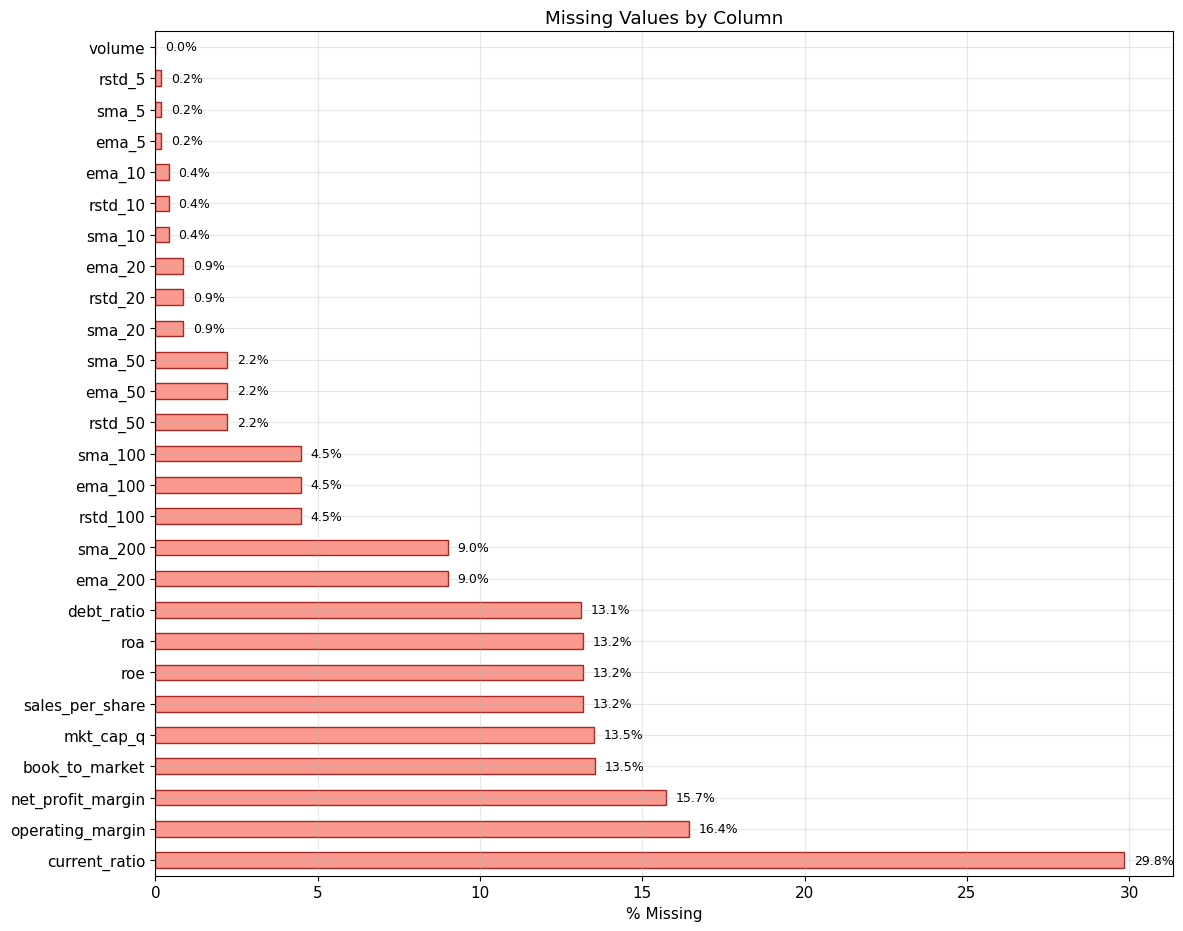

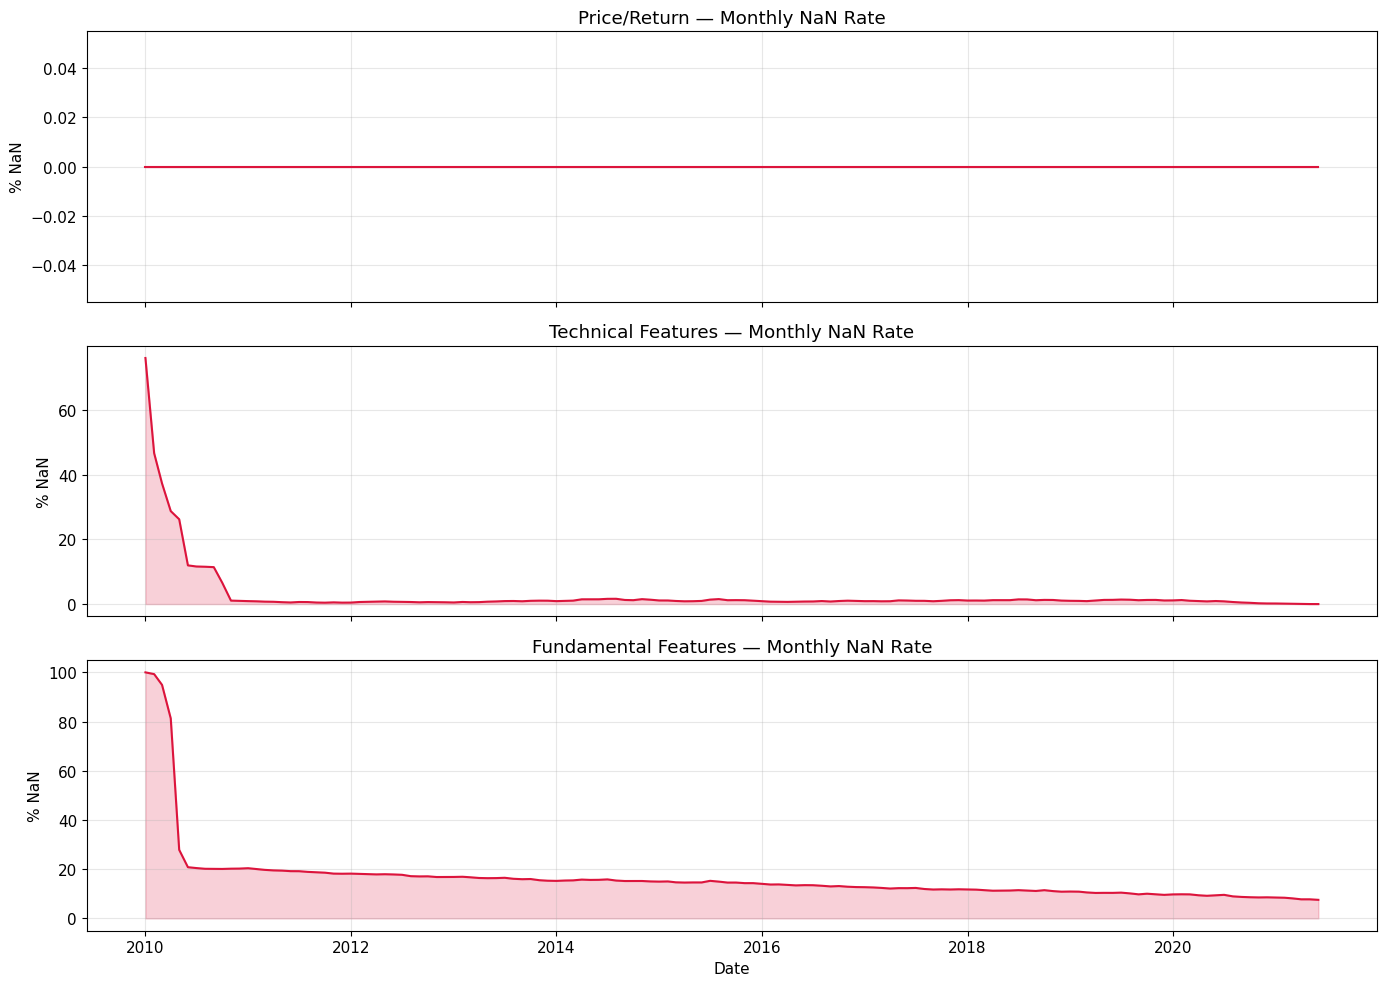

In [3]:
# 2a. NaN rates per column
nan_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]

print("COLUMNS WITH MISSING VALUES (% of rows)")
if nan_pct.empty:
    print("No missing values found!")
else:
    print(nan_pct.round(2).to_string())

fig, ax = plt.subplots(figsize=(12, max(4, len(nan_pct) * 0.35)))
if not nan_pct.empty:
    nan_pct.plot.barh(ax=ax, color="salmon", edgecolor="darkred", alpha=0.8)
    ax.set_xlabel("% Missing")
    ax.set_title("Missing Values by Column")
    for i, v in enumerate(nan_pct):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# 2b. NaN heatmap over time - group by month and check NaN rate for key feature groups

technical_cols = [c for c in df.columns if c.startswith(("sma_", "ema_", "rstd_"))]
fundamental_cols = [
    "sales_per_share", "gross_margin", "operating_margin",
    "net_profit_margin", "roe", "roa", "current_ratio",
    "debt_ratio", "mkt_cap_q", "book_to_market",
]
fundamental_cols = [c for c in fundamental_cols if c in df.columns]
price_cols = [c for c in ["open", "high", "low", "close", "ret"] if c in df.columns]

df["ym"] = df["date"].dt.to_period("M")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, cols, label in zip(
    axes,
    [price_cols, technical_cols, fundamental_cols],
    ["Price/Return", "Technical Features", "Fundamental Features"],
):
    if not cols:
        ax.set_title(f"{label} — no columns found")
        continue
    monthly_nan = df.groupby("ym")[cols].apply(lambda x: x.isna().mean().mean())
    monthly_nan.index = monthly_nan.index.to_timestamp()
    ax.plot(monthly_nan.index, monthly_nan.values * 100, color="crimson", lw=1.5)
    ax.fill_between(monthly_nan.index, monthly_nan.values * 100, alpha=0.2, color="crimson")
    ax.set_ylabel("% NaN")
    ax.set_title(f"{label} — Monthly NaN Rate")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

df.drop(columns="ym", inplace=True)

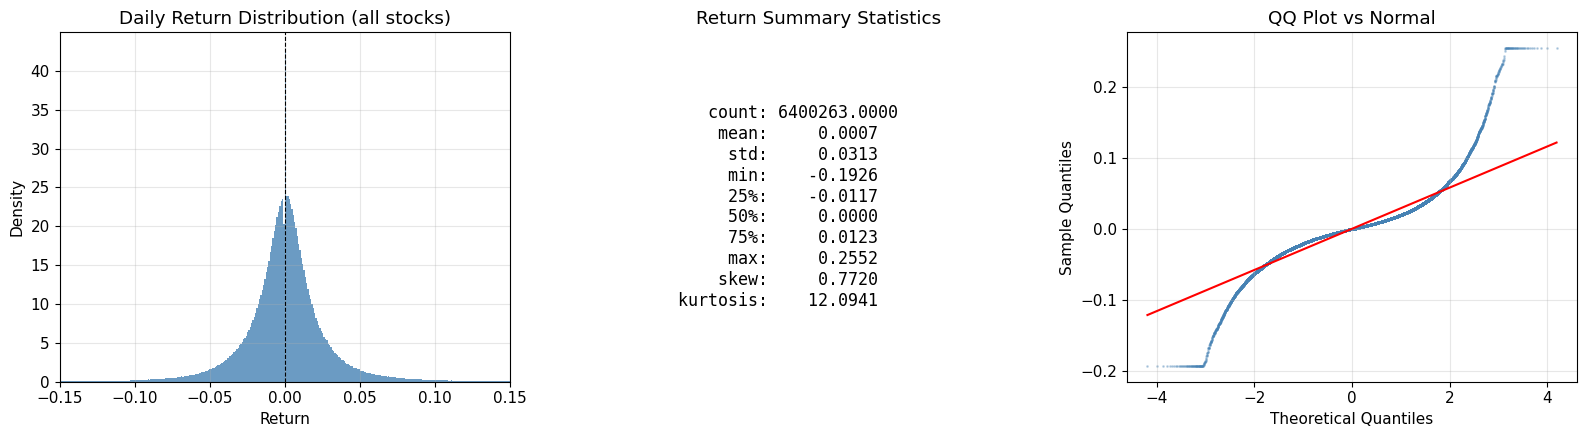

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))


# 3a. Return distribution
axes[0].hist(df["ret"].dropna(), bins=500, color="steelblue",
             edgecolor="none", alpha=0.8, density=True)
axes[0].set_xlim(-0.15, 0.15)
axes[0].axvline(0, color="black", lw=0.8, ls="--")
axes[0].set_title("Daily Return Distribution (all stocks)")
axes[0].set_xlabel("Return")
axes[0].set_ylabel("Density")

# 3b. Return stats
ret_stats = df["ret"].describe()
ret_stats["skew"] = df["ret"].skew()
ret_stats["kurtosis"] = df["ret"].kurtosis()
axes[1].axis("off")
table_text = "\n".join([f"{k:>12s}: {v:>10.4f}" for k, v in ret_stats.items()])
axes[1].text(0.1, 0.5, table_text, fontfamily="monospace", fontsize=12,
             va="center", transform=axes[1].transAxes)
axes[1].set_title("Return Summary Statistics")

# 3c. QQ plot against normal
ret_clean = df["ret"].dropna()
sample = ret_clean.sample(min(50000, len(ret_clean)), random_state=42)
(osm, osr), (slope, intercept, r) = stats.probplot(sample, dist="norm")
axes[2].scatter(osm, osr, s=1, alpha=0.3, color="steelblue")
axes[2].plot(osm, slope * np.array(osm) + intercept, "r-", lw=1.5)
axes[2].set_title("QQ Plot vs Normal")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()


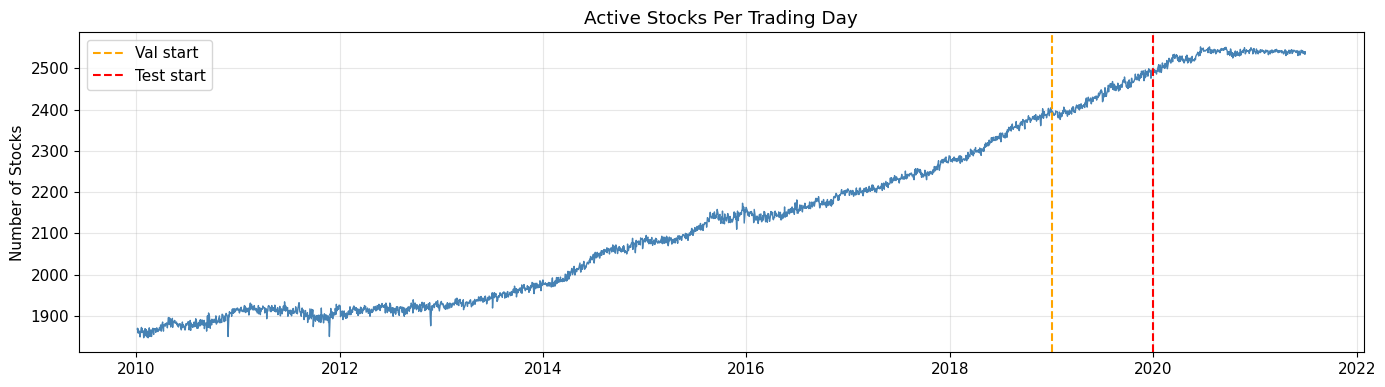

STOCK HISTORY LENGTHS
count    2897.0
mean     2209.0
std      1035.0
min       250.0
25%      1343.0
50%      2848.0
75%      2893.0
max      8679.0


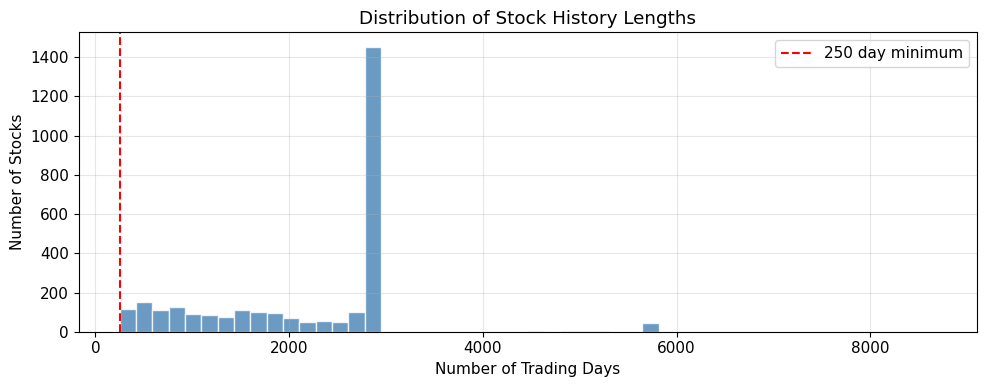

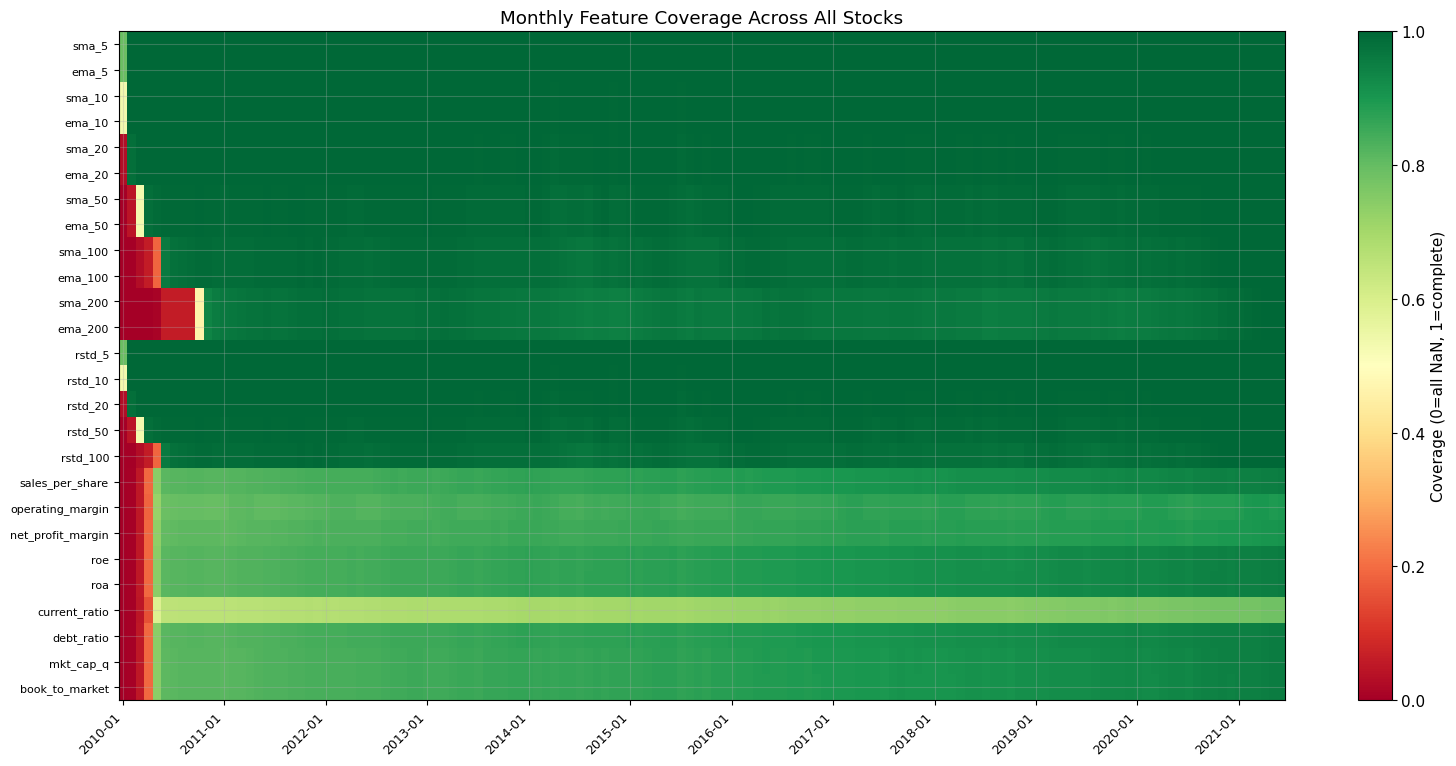

In [6]:
# 4a. Number of active stocks over time
stocks_per_day = df.groupby("date")["permno"].nunique()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(stocks_per_day.index, stocks_per_day.values, lw=1, color="steelblue")
ax.set_ylabel("Number of Stocks")
ax.set_title("Active Stocks Per Trading Day")
ax.axvline(pd.Timestamp("2019-01-01"), color="orange", ls="--", lw=1.5, label="Val start")
ax.axvline(pd.Timestamp("2020-01-01"), color="red", ls="--", lw=1.5, label="Test start")
ax.legend()
plt.tight_layout()
plt.show()

# 4b. Per-stock history length
stock_spans = df.groupby("permno").agg(
    start=("date", "min"),
    end=("date", "max"),
    n_days=("date", "count"),
).sort_values("n_days", ascending=False)

print("STOCK HISTORY LENGTHS")
print(stock_spans["n_days"].describe().round(0).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stock_spans["n_days"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xlabel("Number of Trading Days")
ax.set_ylabel("Number of Stocks")
ax.set_title("Distribution of Stock History Lengths")
ax.axvline(250, color="red", ls="--", lw=1.5, label="250 day minimum")
ax.legend()
plt.tight_layout()
plt.show()

# 4c. Feature coverage heatmap — what % of stocks have each feature on each date?
all_feature_cols = technical_cols + fundamental_cols
if all_feature_cols:
    monthly_coverage = df.set_index("date").resample("M")[all_feature_cols].apply(
        lambda x: x.notna().mean()
    ).T

    fig, ax = plt.subplots(figsize=(16, max(4, len(all_feature_cols) * 0.3)))
    im = ax.imshow(monthly_coverage.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_yticks(range(len(all_feature_cols)))
    ax.set_yticklabels(all_feature_cols, fontsize=8)

    # Show every 12th month on x-axis
    n_months = monthly_coverage.shape[1]
    tick_idx = list(range(0, n_months, 12))
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([monthly_coverage.columns[i].strftime("%Y-%m") for i in tick_idx],
                       rotation=45, ha="right", fontsize=9)

    plt.colorbar(im, ax=ax, label="Coverage (0=all NaN, 1=complete)")
    ax.set_title("Feature Coverage Across All Stocks - Monthly")
    plt.tight_layout()
    plt.show()

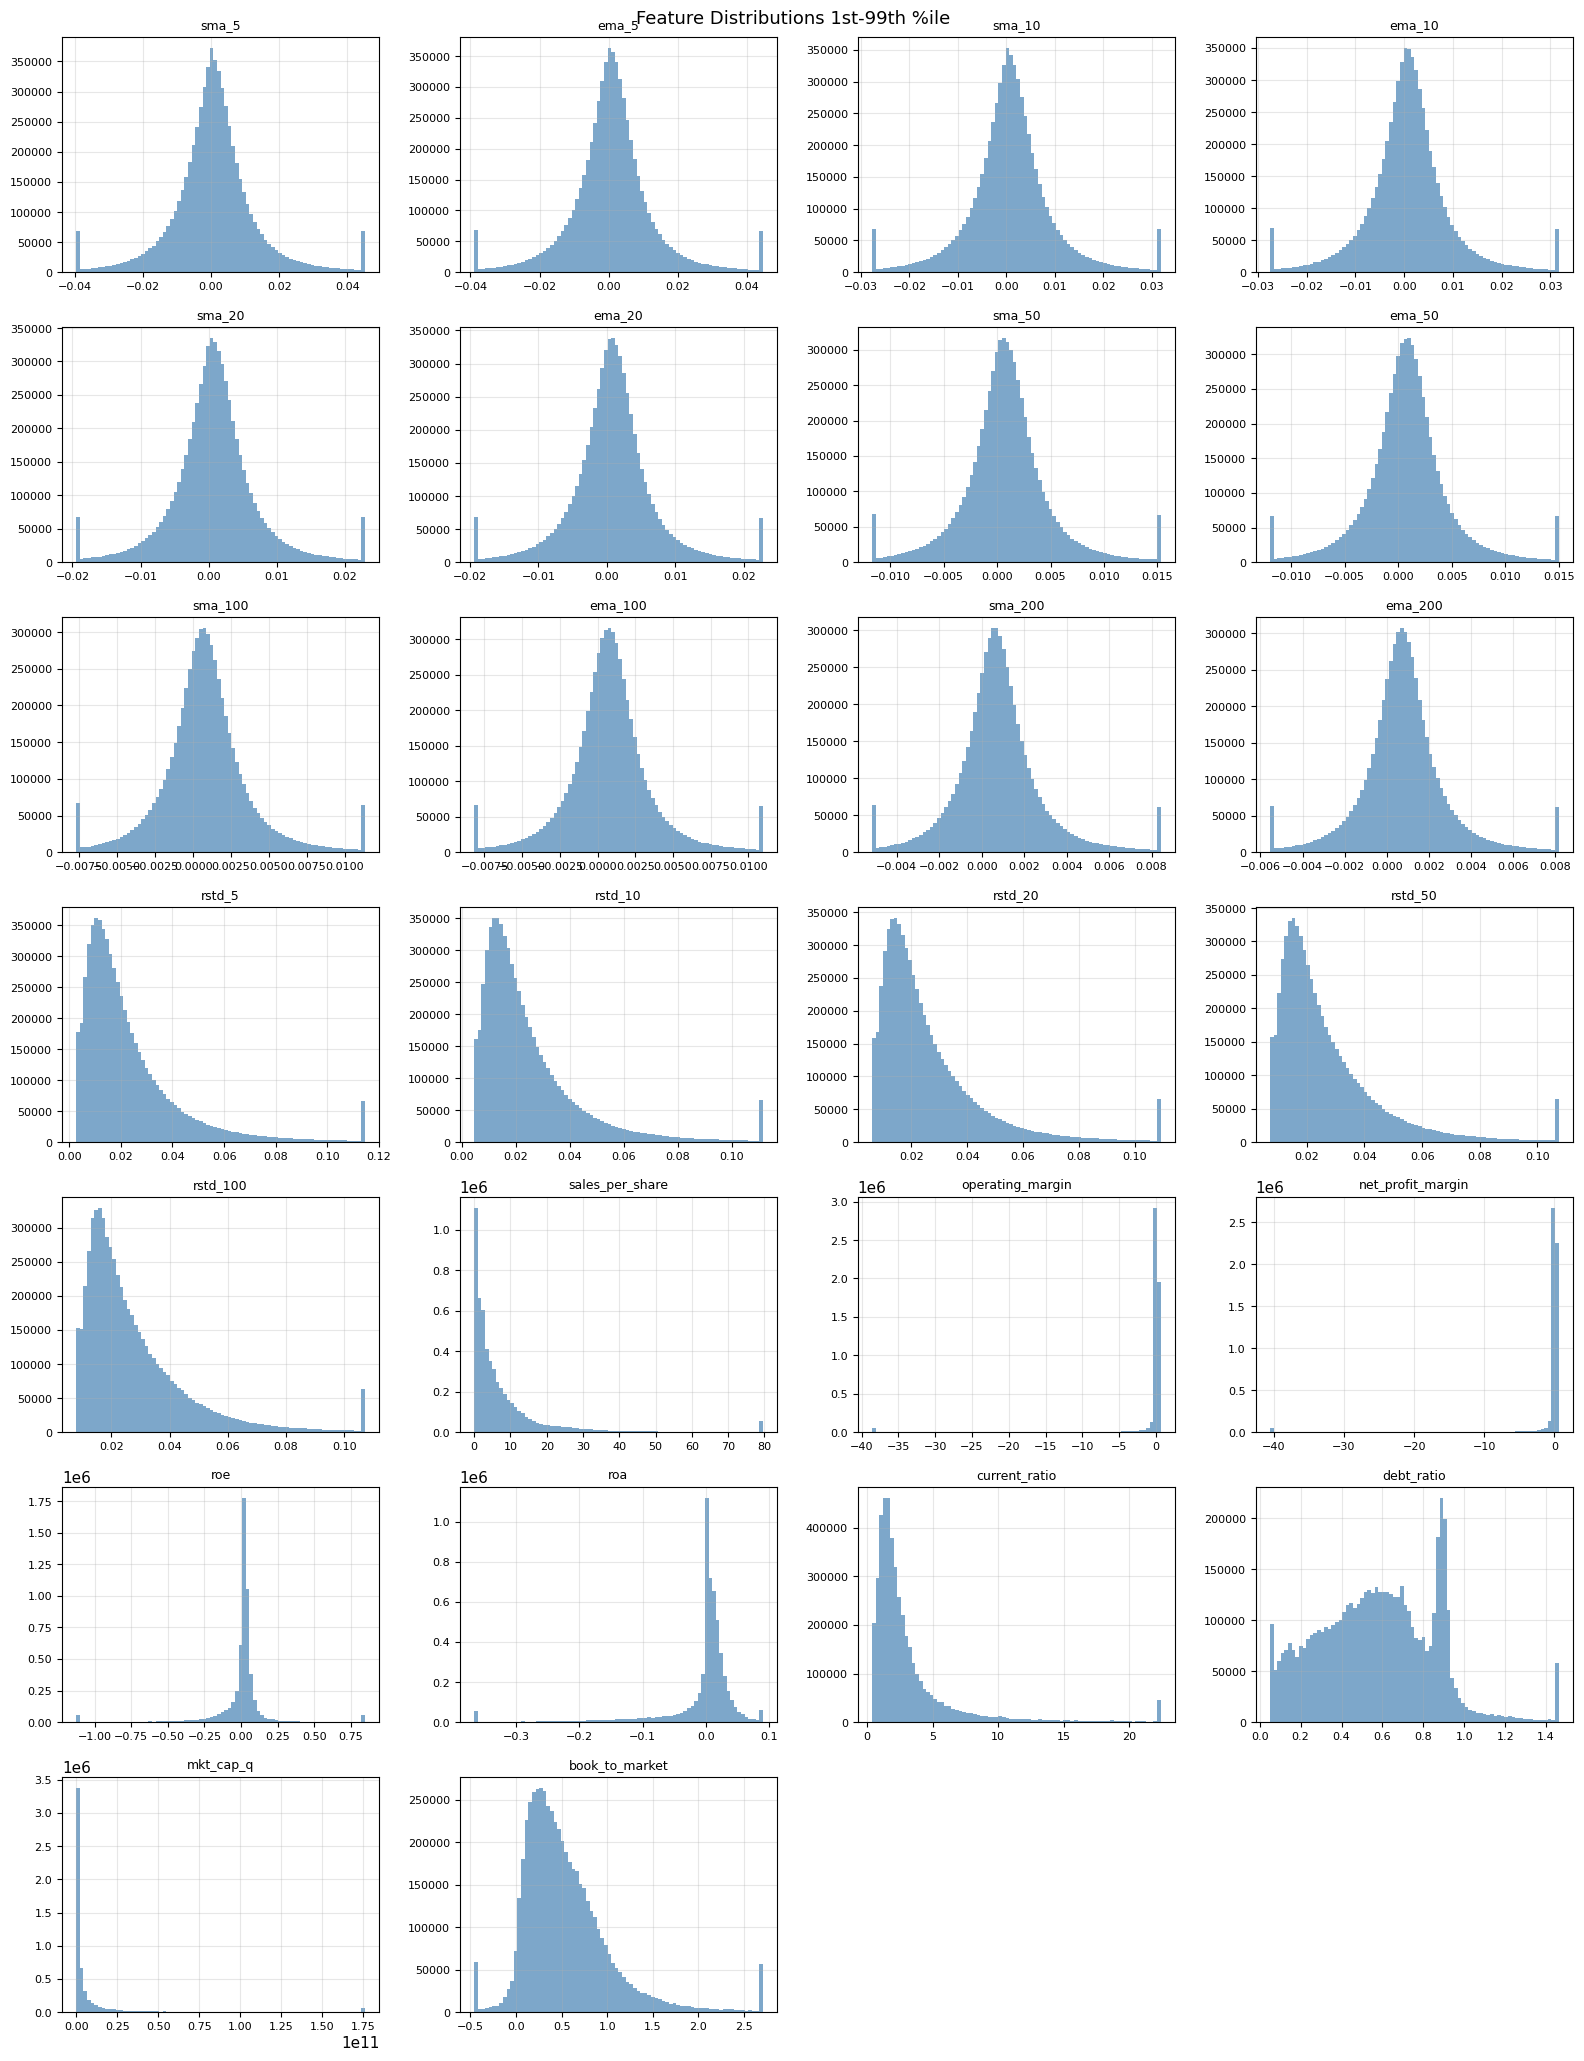

In [8]:
# 5. FEATURE DISTRIBUTIONS (spot outliers / scaling needs)
feature_cols = technical_cols + fundamental_cols
if feature_cols:
    n = len(feature_cols)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        data = df[col].dropna()
        # Clip at 1st/99th percentile for visualization
        lo, hi = data.quantile(0.01), data.quantile(0.99)
        clipped = data.clip(lo, hi)
        axes[i].hist(clipped, bins=80, color="steelblue", edgecolor="none", alpha=0.7)
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(labelsize=8)

    for i in range(len(feature_cols), len(axes)):
        axes[i].axis("off")

    plt.suptitle("Feature Distributions 1st-99th %ile", fontsize=13)
    plt.tight_layout()
    plt.show()

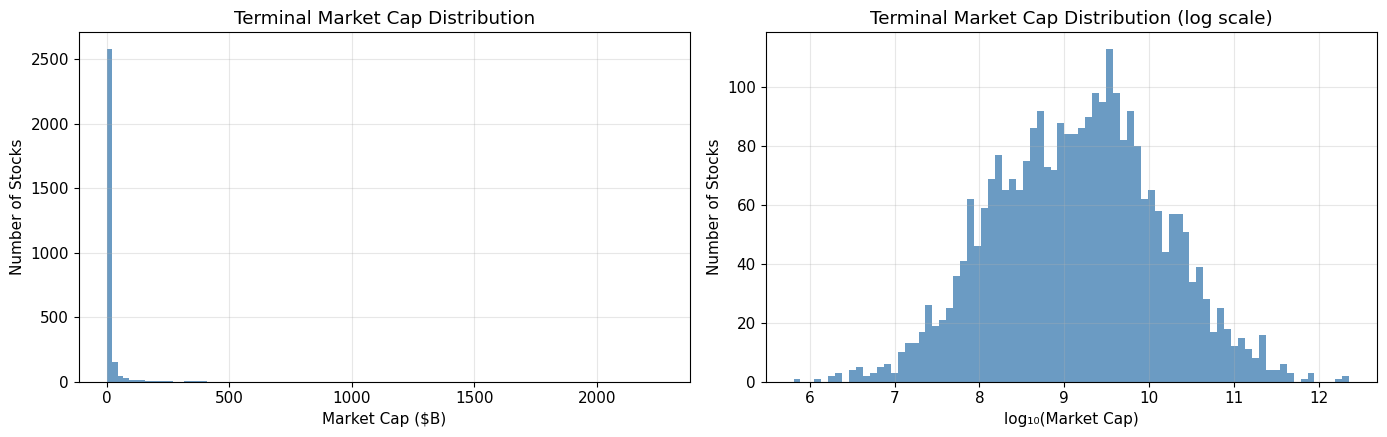

TERMINAL MARKET CAP STATS ($B)
count    2897.00
mean       14.86
std        79.79
min         0.00
25%         0.29
50%         1.56
75%         6.56
max      2267.64


In [9]:
# 6. MARKET CAP DISTRIBUTION (needed for big/small stock splits)

# Last Available(Terminal Market Cap)
terminal_mcap = df.groupby("permno")["mkt_cap"].last().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(terminal_mcap / 1e9, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("Market Cap ($B)")
axes[0].set_ylabel("Number of Stocks")
axes[0].set_title("Terminal Market Cap Distribution")

axes[1].hist(np.log10(terminal_mcap), bins=80, color="steelblue", edgecolor="none", alpha=0.8)
axes[1].set_xlabel("log₁₀(Market Cap)")
axes[1].set_ylabel("Number of Stocks")
axes[1].set_title("Terminal Market Cap Distribution (log scale)")

plt.tight_layout()
plt.show()

print("TERMINAL MARKET CAP STATS ($B)")
print((terminal_mcap / 1e9).describe().round(2).to_string())
